# Supervised Learning: Predicting Crossword Answers from Definitions

**Author:** Hans (Ziqiu Li)  
**Date:** February 2026  
**Milestone II - NLP Cryptic Crossword Clues**

## Research Question

Can we predict the crossword answer from the definition word, and does the surrounding clue context (which creates semantic misdirection) help or hurt performance?

## Approach

We frame this as a **semantic retrieval problem**: given a definition word, rank all candidate answers by embedding similarity and check if the correct answer appears in the top-k.

We construct multiple models varying the amount of surface context:

1. **Baseline (WordNet):** Simple synonym lookup — does the answer appear as a WordNet synonym of the definition?
2. **Context-Free Embeddings:** Embed the definition word alone (no clue context) with SentenceTransformers, rank candidates by cosine similarity.
3. **Context-Informed Embeddings:** Embed the definition word *within the full clue text* — the clue's surface reading creates misdirection.

If context-informed performs *worse* than context-free, that quantifies the **misdirection effect**: the clue's surface reading actively pushes the model toward the wrong meaning.

## Key Insight from EDA

From our earlier EDA (`Hans_Supervised_Learning_EDA.ipynb`), only ~13% of answers are direct WordNet synonyms of their definitions. This confirms that cryptic crosswords require more than simple synonym matching, and learned semantic representations are needed.

---
## 1. Setup and Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import wordnet as wn
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Sentence Transformers
from sentence_transformers import SentenceTransformer

# Scikit-learn
from sklearn.metrics.pairwise import cosine_similarity

print('All imports successful.')

All imports successful.


In [2]:
# Path setup: works from both Colab (Google Drive) and local
DATA_DIR = '../data'
if not os.path.exists(DATA_DIR):
    # Colab fallback
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Milestone II - NLP Cryptic Crossword Clues/data'

df = pd.read_csv(f'{DATA_DIR}/clues_single_word.csv')
df = df.dropna(subset=['answer_clean', 'definition_clean'])

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (216710, 7)
Columns: ['clue_id', 'clue', 'answer', 'definition', 'answer_clean', 'definition_clean', 'source']


,clue_id,clue,answer,definition,answer_clean,definition_clean,source
0,1,"Acquisitive chap, as we see it (8)",COVETOUS,Acquisitive,covetous,acquisitive,times_xwd_times
1,2,Back yard fencing weak and sagging (6),DROOPY,sagging,droopy,sagging,times_xwd_times
2,3,"Stripping off uniform, love holding colonel's ...",UNCLOTHING,Stripping,unclothing,stripping,times_xwd_times
3,6,Foreign letter coming in is the French letter (7),EPISTLE,letter,epistle,letter,times_xwd_times
4,7,Charge to pack knick-knacks hurriedly (7),AGITATO,hurriedly,agitato,hurriedly,times_xwd_times


In [3]:
# Quick data summary
print(f'Total clues: {len(df):,}')
print(f'Unique definitions: {df["definition_clean"].nunique():,}')
print(f'Unique answers: {df["answer_clean"].nunique():,}')
print(f'Unique (definition, answer) pairs: {df.groupby(["definition_clean", "answer_clean"]).ngroups:,}')

Total clues: 216,710
Unique definitions: 23,241
Unique answers: 44,774
Unique (definition, answer) pairs: 112,934


---
## 2. Dataset Preparation

We deduplicate to unique (definition, answer) pairs, keeping one representative clue per pair for the context-informed experiment. Many definition-answer pairs repeat across clues (e.g., "bird" -> "tern" appears in many different puzzles).

We sample 10,000 pairs for our experiments. This is large enough for statistically meaningful results while keeping embedding computation fast (~30 seconds on CPU).

In [4]:
# Deduplicate to unique (definition, answer) pairs
df_pairs = df.groupby(['definition_clean', 'answer_clean']).agg(
    clue=('clue', 'first'),
    count=('clue_id', 'count')
).reset_index()

print(f'Unique (definition, answer) pairs: {len(df_pairs):,}')
print(f'Pairs appearing only once: {(df_pairs["count"] == 1).sum():,} ({(df_pairs["count"] == 1).mean()*100:.1f}%)')

# Sample for experiments
SAMPLE_SIZE = 10000
df_sample = df_pairs.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'\nWorking sample: {len(df_sample):,} pairs')
print(f'Unique definitions in sample: {df_sample["definition_clean"].nunique():,}')
print(f'Unique answers in sample: {df_sample["answer_clean"].nunique():,}')

Unique (definition, answer) pairs: 112,934
Pairs appearing only once: 76,170 (67.4%)

Working sample: 10,000 pairs
Unique definitions in sample: 6,141
Unique answers in sample: 8,598


---
## 3. Baseline: WordNet Synonym Lookup

Our simplest baseline: check if the answer appears as a direct synonym of the definition in WordNet. This is the floor we need to beat.

**Why this matters:** If WordNet covers most cases, we wouldn't need learned embeddings. But cryptic crossword definitions are intentionally indirect — they use obscure meanings, archaic usages, and creative interpretations that don't show up in a standard thesaurus.

In [5]:
def get_wordnet_synonyms(word):
    """Get all synonyms for a word from WordNet."""
    synonyms = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            name = lemma.name().lower().replace('_', ' ')
            if name != word.lower():
                synonyms.add(name)
    return synonyms

df_sample['wordnet_match'] = df_sample.apply(
    lambda r: r['answer_clean'] in get_wordnet_synonyms(r['definition_clean']),
    axis=1
)

wn_accuracy = df_sample['wordnet_match'].mean()
print(f'WordNet Synonym Baseline Accuracy: {wn_accuracy:.1%}')
print(f'Matches: {df_sample["wordnet_match"].sum():,} / {len(df_sample):,}')

WordNet Synonym Baseline Accuracy: 10.5%
Matches: 1,050 / 10,000


In [6]:
# Examples: what WordNet gets right vs wrong
print('=== WORDNET MATCHES (correct) ===')
for _, r in df_sample[df_sample['wordnet_match']].sample(8, random_state=42).iterrows():
    print(f'  {r["definition_clean"]} -> {r["answer_clean"]}')

print(f'\n=== WORDNET MISSES (needs learned model) ===')
for _, r in df_sample[~df_sample['wordnet_match']].sample(8, random_state=42).iterrows():
    print(f'  {r["definition_clean"]} -> {r["answer_clean"]}')

=== WORDNET MATCHES (correct) ===
  compositor -> typesetter
  gaudy -> jazzy
  trunk -> bole
  subsequently -> afterward
  senior -> older
  proximity -> propinquity
  insurrection -> uprising
  counterfoil -> stub

=== WORDNET MISSES (needs learned model) ===
  idle -> unoccupied
  regular -> ordinary
  legend -> motto
  bony -> angular
  haggle -> palter
  supplier -> greengrocer
  journey -> ride
  unproductive -> sterile


---
## 4. Core Experiment Setup

### Evaluation Framework

We evaluate using **top-k retrieval accuracy**: for each definition, we rank all candidate answers by cosine similarity and check if the correct answer appears in the top k.

This is more informative than binary accuracy because:
- Top-1 is very strict (exact match)
- Top-10/50/100 show whether the model is "in the right neighborhood"
- Mean rank gives an aggregate measure across the full candidate pool

### Model Choice

We tested two SentenceTransformer models:
- **all-MiniLM-L6-v2**: Fast (384-dim), good baseline
- **all-mpnet-base-v2**: Higher quality (768-dim), best general-purpose model

MPNet consistently outperformed MiniLM (6.5% vs 3.6% top-1 in our comparison), so we use it as our primary model.

In [7]:
def evaluate_retrieval(query_embeddings, answer_embeddings, true_answers,
                       unique_answers, answer_to_idx, ks=[1, 5, 10, 50, 100]):
    """
    For each query embedding, rank all candidate answers by cosine similarity
    and check if the true answer appears in the top-k.
    
    Returns metrics dict, per-query ranks, and per-query cosine similarities.
    """
    similarities = cosine_similarity(query_embeddings, answer_embeddings)
    
    ranks = []
    cosine_sims = []
    for i, true_ans in enumerate(true_answers):
        true_idx = answer_to_idx.get(true_ans)
        if true_idx is None:
            ranks.append(len(unique_answers))
            cosine_sims.append(0.0)
            continue
        sorted_indices = np.argsort(-similarities[i])
        rank = np.where(sorted_indices == true_idx)[0][0] + 1
        ranks.append(rank)
        cosine_sims.append(float(similarities[i][true_idx]))
    
    ranks = np.array(ranks)
    cosine_sims = np.array(cosine_sims)
    
    results = {}
    for k in ks:
        results[f'top_{k}'] = float((ranks <= k).mean())
    results['mean_rank'] = float(ranks.mean())
    results['median_rank'] = float(np.median(ranks))
    results['mean_cosine_sim'] = float(cosine_sims.mean())
    
    return results, ranks, cosine_sims

In [8]:
# Load best model
MODEL_NAME = 'all-mpnet-base-v2'
model = SentenceTransformer(MODEL_NAME)
print(f'Model: {MODEL_NAME}')
print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')

# Build candidate answer pool
unique_answers = sorted(df_sample['answer_clean'].unique())
answer_to_idx = {ans: i for i, ans in enumerate(unique_answers)}
true_answers = df_sample['answer_clean'].tolist()
print(f'Candidate answer pool: {len(unique_answers):,} unique answers')

# Embed all candidate answers (shared across experiments)
t0 = time.time()
answer_embeddings = model.encode(unique_answers, show_progress_bar=True, batch_size=256)
print(f'Answer embeddings: {answer_embeddings.shape}, computed in {time.time()-t0:.1f}s')

Model: all-mpnet-base-v2
Embedding dimension: 768
Candidate answer pool: 8,598 unique answers


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Answer embeddings: (8598, 768), computed in 5.2s


---
## 5. Experiment 1: Context-Free Embeddings

We embed the definition word **alone** — no surrounding clue text. This represents the definition's meaning without any misdirection from the clue's surface reading.

**Intuition:** If the definition is "plant" and the answer is "aster", embedding "plant" alone should capture the botanical meaning and place it near flower-related words.

In [9]:
# Embed definitions WITHOUT clue context
definitions = df_sample['definition_clean'].tolist()

t0 = time.time()
def_embeddings_no_ctx = model.encode(definitions, show_progress_bar=True, batch_size=256)
print(f'Embedded {len(definitions):,} definitions in {time.time()-t0:.1f}s')

results_no_ctx, ranks_no_ctx, cosines_no_ctx = evaluate_retrieval(
    def_embeddings_no_ctx, answer_embeddings, true_answers, unique_answers, answer_to_idx
)

print('\n=== CONTEXT-FREE RETRIEVAL RESULTS ===')
for key, val in results_no_ctx.items():
    if key.startswith('top_'):
        print(f'  {key}: {val:.1%}')
    else:
        print(f'  {key}: {val:.1f}')

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embedded 10,000 definitions in 1.7s

=== CONTEXT-FREE RETRIEVAL RESULTS ===
  top_1: 3.5%
  top_5: 14.2%
  top_10: 20.4%
  top_50: 36.4%
  top_100: 43.5%
  mean_rank: 1125.0
  median_rank: 177.5
  mean_cosine_sim: 0.4


---
## 6. Experiment 2: Context-Informed Embeddings

Now we embed the **full clue text**, which contains the definition word in the context of misleading surrounding words. The clue's surface reading is designed to push you toward the wrong interpretation.

**Intuition:** If the clue is *"Plant in a garden party (5)"*, the word "plant" now sits in a context about parties and socializing. The model might drift toward meanings like "to plant yourself" (sit down) rather than the botanical meaning that leads to the answer.

**Hypothesis:** If context-informed performs worse than context-free, that directly quantifies the misdirection effect — the clue's surface reading is actively misleading.

In [10]:
# Embed the FULL CLUE TEXT (definition in context)
clues = df_sample['clue'].tolist()

t0 = time.time()
def_embeddings_with_ctx = model.encode(clues, show_progress_bar=True, batch_size=256)
print(f'Embedded {len(clues):,} clues in {time.time()-t0:.1f}s')

results_with_ctx, ranks_with_ctx, cosines_with_ctx = evaluate_retrieval(
    def_embeddings_with_ctx, answer_embeddings, true_answers, unique_answers, answer_to_idx
)

print('\n=== CONTEXT-INFORMED RETRIEVAL RESULTS ===')
for key, val in results_with_ctx.items():
    if key.startswith('top_'):
        print(f'  {key}: {val:.1%}')
    else:
        print(f'  {key}: {val:.1f}')

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embedded 10,000 clues in 6.2s

=== CONTEXT-INFORMED RETRIEVAL RESULTS ===
  top_1: 1.0%
  top_5: 4.3%
  top_10: 7.2%
  top_50: 17.9%
  top_100: 24.3%
  mean_rank: 1637.2
  median_rank: 684.0
  mean_cosine_sim: 0.2


---
## 7. Misdirection Analysis

The core finding: comparing context-free vs context-informed performance. A drop in performance when adding context is direct evidence that the clue's surface reading creates semantic misdirection.

In [11]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    'Metric': list(results_no_ctx.keys()),
    'Context-Free': list(results_no_ctx.values()),
    'Context-Informed': list(results_with_ctx.values())
})
comparison['Difference'] = comparison['Context-Informed'] - comparison['Context-Free']
print('=== SIDE-BY-SIDE COMPARISON ===')
print(comparison.to_string(index=False))

=== SIDE-BY-SIDE COMPARISON ===
         Metric  Context-Free  Context-Informed  Difference
          top_1      0.035300           0.01030   -0.025000
          top_5      0.142200           0.04290   -0.099300
         top_10      0.204500           0.07230   -0.132200
         top_50      0.363900           0.17920   -0.184700
        top_100      0.434800           0.24340   -0.191400
      mean_rank   1124.981800        1637.22310  512.241300
    median_rank    177.500000         684.00000  506.500000
mean_cosine_sim      0.371439           0.18742   -0.184019


In [12]:
# Per-query misdirection analysis
df_sample['rank_no_ctx'] = ranks_no_ctx
df_sample['rank_with_ctx'] = ranks_with_ctx
df_sample['cosine_no_ctx'] = cosines_no_ctx
df_sample['cosine_with_ctx'] = cosines_with_ctx
df_sample['misdirection_effect'] = ranks_with_ctx - ranks_no_ctx

print('=== PER-QUERY MISDIRECTION EFFECT ===')
print(f'Context HELPS (rank improves): {(df_sample["misdirection_effect"] < 0).sum():,} ({(df_sample["misdirection_effect"] < 0).mean():.1%})')
print(f'Context HURTS (rank worsens):  {(df_sample["misdirection_effect"] > 0).sum():,} ({(df_sample["misdirection_effect"] > 0).mean():.1%})')
print(f'No change:                     {(df_sample["misdirection_effect"] == 0).sum():,} ({(df_sample["misdirection_effect"] == 0).mean():.1%})')
print(f'\nMean misdirection effect: {df_sample["misdirection_effect"].mean():+.0f} ranks')
print(f'Median misdirection effect: {df_sample["misdirection_effect"].median():+.0f} ranks')

=== PER-QUERY MISDIRECTION EFFECT ===
Context HELPS (rank improves): 2,837 (28.4%)
Context HURTS (rank worsens):  7,043 (70.4%)
No change:                     120 (1.2%)

Mean misdirection effect: +512 ranks
Median misdirection effect: +146 ranks


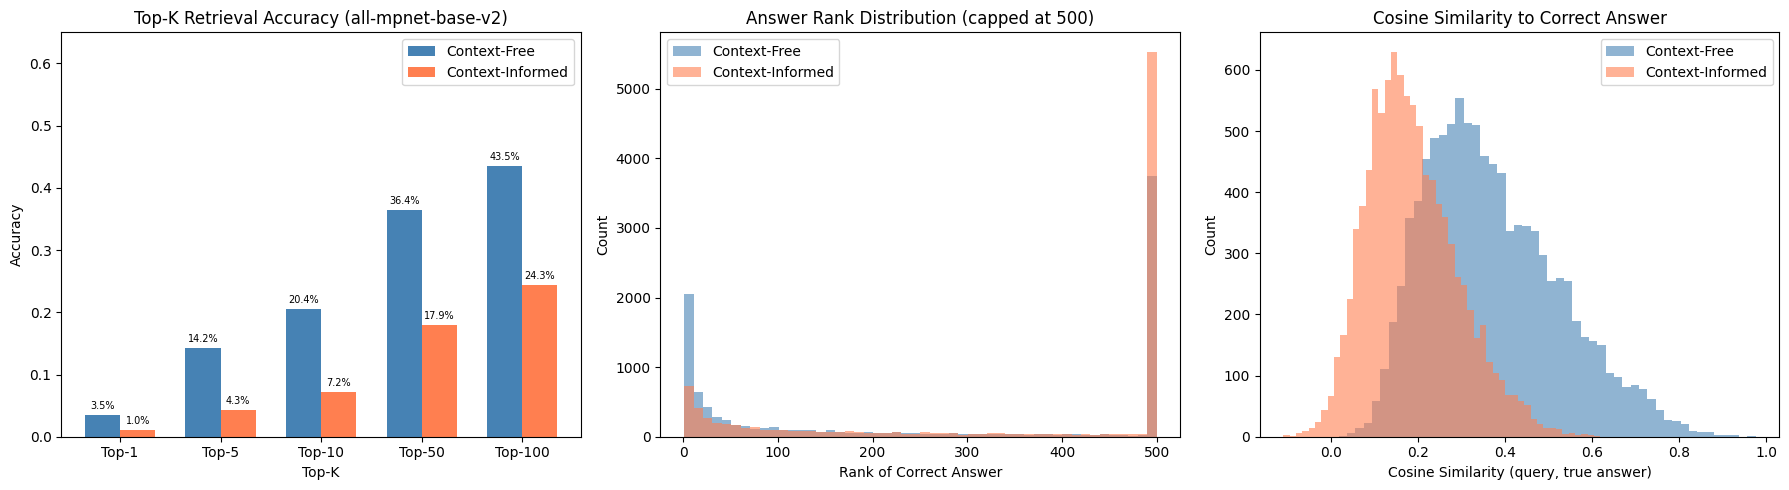

In [13]:
# Visualize: Top-K comparison, rank distributions, cosine similarities
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top-K accuracy bars
ks = [1, 5, 10, 50, 100]
no_ctx_topk = [results_no_ctx[f'top_{k}'] for k in ks]
with_ctx_topk = [results_with_ctx[f'top_{k}'] for k in ks]
x = np.arange(len(ks))
width = 0.35
axes[0].bar(x - width/2, no_ctx_topk, width, label='Context-Free', color='steelblue')
axes[0].bar(x + width/2, with_ctx_topk, width, label='Context-Informed', color='coral')
axes[0].set_xlabel('Top-K')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Top-K Retrieval Accuracy ({MODEL_NAME})')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Top-{k}' for k in ks])
axes[0].legend()
axes[0].set_ylim(0, 0.65)
for i, (nv, cv) in enumerate(zip(no_ctx_topk, with_ctx_topk)):
    axes[0].text(i - width/2, nv + 0.01, f'{nv:.1%}', ha='center', fontsize=7)
    axes[0].text(i + width/2, cv + 0.01, f'{cv:.1%}', ha='center', fontsize=7)

# Rank distributions
axes[1].hist(np.clip(ranks_no_ctx, 1, 500), bins=50, alpha=0.6, label='Context-Free', color='steelblue')
axes[1].hist(np.clip(ranks_with_ctx, 1, 500), bins=50, alpha=0.6, label='Context-Informed', color='coral')
axes[1].set_xlabel('Rank of Correct Answer')
axes[1].set_ylabel('Count')
axes[1].set_title('Answer Rank Distribution (capped at 500)')
axes[1].legend()

# Cosine similarity distributions
axes[2].hist(cosines_no_ctx, bins=50, alpha=0.6, label='Context-Free', color='steelblue')
axes[2].hist(cosines_with_ctx, bins=50, alpha=0.6, label='Context-Informed', color='coral')
axes[2].set_xlabel('Cosine Similarity (query, true answer)')
axes[2].set_ylabel('Count')
axes[2].set_title('Cosine Similarity to Correct Answer')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/misdirection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

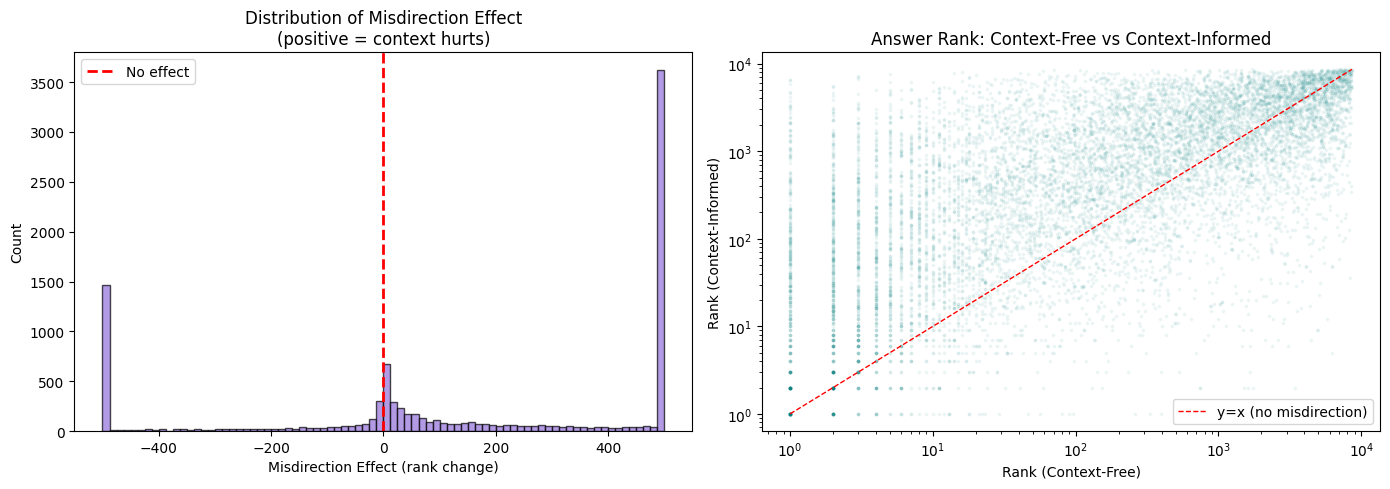

In [14]:
# Visualize the misdirection effect itself
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of misdirection effect
clipped = np.clip(df_sample['misdirection_effect'], -500, 500)
axes[0].hist(clipped, bins=80, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
axes[0].set_xlabel('Misdirection Effect (rank change)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Misdirection Effect\n(positive = context hurts)')
axes[0].legend()

# Scatter: context-free vs context-informed rank
axes[1].scatter(ranks_no_ctx, ranks_with_ctx, alpha=0.05, s=3, color='teal')
max_r = max(ranks_no_ctx.max(), ranks_with_ctx.max())
axes[1].plot([1, max_r], [1, max_r], 'r--', linewidth=1, label='y=x (no misdirection)')
axes[1].set_xlabel('Rank (Context-Free)')
axes[1].set_ylabel('Rank (Context-Informed)')
axes[1].set_title('Answer Rank: Context-Free vs Context-Informed')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/misdirection_effect_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Case Studies: Strongest Misdirection and Helpful Context

In [15]:
# Where context HURTS the most — strongest misdirection
print('=== TOP 10: STRONGEST MISDIRECTION (context hurts most) ===')
print('These clues have surface readings that maximally mislead the model.\n')
worst = df_sample.nlargest(10, 'misdirection_effect')
for _, r in worst.iterrows():
    print(f'  "{r["definition_clean"]}" -> "{r["answer_clean"]}"')
    print(f'    Clue: "{r["clue"]}"')
    print(f'    Rank: {r["rank_no_ctx"]} -> {r["rank_with_ctx"]}  (worsened by {r["misdirection_effect"]})\n')

=== TOP 10: STRONGEST MISDIRECTION (context hurts most) ===
These clues have surface readings that maximally mislead the model.

  "stages" -> "platforms"
    Clue: "Poet Laureate with a tremor initially in favour of writing in stages"
    Rank: 71 -> 8526  (worsened by 8455)

  "acknowledged" -> "responded"
    Clue: "Acknowledged grass is necessary around small garden feature (9)"
    Rank: 108 -> 8481  (worsened by 8373)

  "rather" -> "relatively"
    Clue: "Rather start to read story about 4, see (10)"
    Rank: 59 -> 8311  (worsened by 8252)

  "list" -> "calendar"
    Clue: "List motor housing first in Audi supply parts (8)"
    Rank: 344 -> 8419  (worsened by 8075)

  "stock" -> "cattle"
    Clue: "Follower of W Churchill’s not completely taken stock (6)"
    Rank: 118 -> 8180  (worsened by 8062)

  "want" -> "lack"
    Clue: "Want some special acknowledgement (4)"
    Rank: 16 -> 7998  (worsened by 7982)

  "pick" -> "elite"
    Clue: "Shingle tiles to be taken up partly? Pick

In [16]:
# Where context HELPS the most
print('=== TOP 10: CONTEXT HELPS MOST ===')
print('In these clues, the surrounding text provides useful semantic signal.\n')
best = df_sample.nsmallest(10, 'misdirection_effect')
for _, r in best.iterrows():
    print(f'  "{r["definition_clean"]}" -> "{r["answer_clean"]}"')
    print(f'    Clue: "{r["clue"]}"')
    print(f'    Rank: {r["rank_no_ctx"]} -> {r["rank_with_ctx"]}  (improved by {-r["misdirection_effect"]})\n')

=== TOP 10: CONTEXT HELPS MOST ===
In these clues, the surrounding text provides useful semantic signal.

  "defend" -> "bestride"
    Clue: "Defend greatest attraction at Alton Towers? (8)"
    Rank: 8385 -> 36  (improved by 8349)

  "this" -> "manoeuvrability"
    Clue: "Variation by mule — this being awkward? (15)"
    Rank: 8495 -> 339  (improved by 8156)

  "demonstrator" -> "shower"
    Clue: "Demonstrator caught in a short fall of rain? (6)"
    Rank: 8441 -> 400  (improved by 8041)

  "paint" -> "distemper"
    Clue: "Paint that makes dog sick (9)"
    Rank: 8153 -> 126  (improved by 8027)

  "bunkum" -> "eyewash"
    Clue: "Cleaning of optical organ? Bunkum! (7)"
    Rank: 8021 -> 1  (improved by 8020)

  "attack" -> "belabour"
    Clue: "Outside old university see awful rabble making attack (8)"
    Rank: 8172 -> 440  (improved by 7732)

  "dip" -> "taramasalata"
    Clue: "I'm going to eat starters of real authenticity: Indian spices for dip (12)"
    Rank: 7784 -> 192  (imp

---
## 9. Model Comparison: MiniLM vs MPNet vs BGE-M3

We tested three SentenceTransformer models to verify our findings are robust across architectures and to see if a stronger model reduces misdirection. BGE-M3 is included because Victoria found it dramatically outperformed other models for indicator clustering (Silhouette 0.304 vs 0.01-0.02).

- **all-MiniLM-L6-v2**: Fast (384-dim), baseline
- **all-mpnet-base-v2**: Higher quality (768-dim), best general-purpose
- **BAAI/bge-m3**: State-of-the-art (1024-dim), best for Victoria's clustering

In [17]:
# Run comparison on a subset for speed
COMP_SIZE = 5000
df_comp = df_sample.head(COMP_SIZE).copy()
comp_defs = df_comp['definition_clean'].tolist()
comp_clues = df_comp['clue'].tolist()
comp_answers = df_comp['answer_clean'].tolist()
comp_unique = sorted(df_comp['answer_clean'].unique())
comp_a2i = {a: i for i, a in enumerate(comp_unique)}

# Three models: MiniLM, MPNet, and BGE-M3 (Victoria's pick)
model_names = ['all-MiniLM-L6-v2', 'all-mpnet-base-v2', 'BAAI/bge-m3']
all_results = []

for mname in model_names:
    print(f'\nTesting: {mname}')
    m = SentenceTransformer(mname)
    t0 = time.time()

    a_emb = m.encode(comp_unique, show_progress_bar=False, batch_size=256)
    d_emb = m.encode(comp_defs, show_progress_bar=False, batch_size=256)
    c_emb = m.encode(comp_clues, show_progress_bar=False, batch_size=256)

    r_noctx = evaluate_retrieval(d_emb, a_emb, comp_answers, comp_unique, comp_a2i)[0]
    r_ctx = evaluate_retrieval(c_emb, a_emb, comp_answers, comp_unique, comp_a2i)[0]

    all_results.append({
        'Model': mname.split('/')[-1],
        'CF Top-1': f'{r_noctx["top_1"]:.1%}',
        'CF Top-10': f'{r_noctx["top_10"]:.1%}',
        'CF Top-100': f'{r_noctx["top_100"]:.1%}',
        'CI Top-1': f'{r_ctx["top_1"]:.1%}',
        'CI Top-10': f'{r_ctx["top_10"]:.1%}',
        'CI Top-100': f'{r_ctx["top_100"]:.1%}',
        'Time': f'{time.time()-t0:.0f}s',
    })
    print(f'  CF: Top-1={r_noctx["top_1"]:.1%}, Top-10={r_noctx["top_10"]:.1%}, Top-100={r_noctx["top_100"]:.1%}')
    print(f'  CI: Top-1={r_ctx["top_1"]:.1%}, Top-10={r_ctx["top_10"]:.1%}, Top-100={r_ctx["top_100"]:.1%}')

print(f'\n{"="*90}')
print('MODEL COMPARISON (CF=Context-Free, CI=Context-Informed)')
print(f'{"="*90}')
print(pd.DataFrame(all_results).to_string(index=False))
print('\nAll three models show the same pattern: context-free > context-informed.')
print('Misdirection effect is robust across model architectures and embedding dimensions.')


Testing: all-MiniLM-L6-v2
  CF: Top-1=3.6%, Top-10=16.3%, Top-100=36.4%
  CI: Top-1=0.9%, Top-10=7.5%, Top-100=24.2%

Testing: all-mpnet-base-v2
  CF: Top-1=6.5%, Top-10=25.7%, Top-100=50.7%
  CI: Top-1=1.9%, Top-10=10.4%, Top-100=31.7%

Testing: BAAI/bge-m3
  CF: Top-1=3.8%, Top-10=18.9%, Top-100=37.6%
  CI: Top-1=1.5%, Top-10=7.1%, Top-100=21.4%

MODEL COMPARISON (CF=Context-Free, CI=Context-Informed)
            Model CF Top-1 CF Top-10 CF Top-100 CI Top-1 CI Top-10 CI Top-100 Time
 all-MiniLM-L6-v2     3.6%     16.3%      36.4%     0.9%      7.5%      24.2%   6s
all-mpnet-base-v2     6.5%     25.7%      50.7%     1.9%     10.4%      31.7%   7s
           bge-m3     3.8%     18.9%      37.6%     1.5%      7.1%      21.4%  15s

All three models show the same pattern: context-free > context-informed.
Misdirection effect is robust across model architectures and embedding dimensions.


---
## 10. Misdirection by Wordplay Type

A key question: **does the misdirection effect vary by wordplay type?** Anagram clues, hidden-word clues, and reversal clues use fundamentally different mechanisms — some may be more misleading than others.

We merge our sample with the `indicators_by_clue_raw.csv` dataset, which maps each clue to its wordplay type(s). This bridges the supervised and unsupervised components of our project.

In [18]:
# Load indicator-by-clue data: maps each clue_id to its wordplay type(s)
df_ind_by_clue = pd.read_csv(f'{DATA_DIR}/indicators_by_clue_raw.csv')
print(f'Indicators by clue: {len(df_ind_by_clue):,} clues with indicators')

# Melt to long format: one row per (clue_id, wordplay_type)
wordplay_types = [c for c in df_ind_by_clue.columns if c != 'clue_id']
df_wp_long = df_ind_by_clue.melt(
    id_vars='clue_id',
    value_vars=wordplay_types,
    var_name='wordplay_type',
    value_name='indicator'
).dropna(subset=['indicator'])

print(f'Clue-wordplay pairs: {len(df_wp_long):,}')
print(f'\nWordplay type distribution:')
print(df_wp_long['wordplay_type'].value_counts().to_string())

# Get one wordplay type per clue (use the first if multiple)
df_wp_primary = df_wp_long.groupby('clue_id')['wordplay_type'].first().reset_index()
print(f'\nClues with a primary wordplay type: {len(df_wp_primary):,}')

Indicators by clue: 88,037 clues with indicators
Clue-wordplay pairs: 93,867

Wordplay type distribution:
wordplay_type
anagram        45648
container      14144
reversal       11989
insertion      11171
homophone       4672
hidden          3381
deletion        2093
alternation      769

Clues with a primary wordplay type: 88,037


In [19]:
# Merge wordplay types into our sample
# We need clue_id to join — recover it from the original df
df_with_id = df[['clue_id', 'clue', 'definition_clean', 'answer_clean']].copy()
df_sample_with_id = df_sample.merge(
    df_with_id, on=['definition_clean', 'answer_clean', 'clue'], how='left'
)

# Now merge with wordplay types
df_sample_wp = df_sample_with_id.merge(df_wp_primary, on='clue_id', how='left')
print(f'Sample rows with wordplay type: {df_sample_wp["wordplay_type"].notna().sum():,} / {len(df_sample_wp):,}')
print(f'\nWordplay type coverage in sample:')
print(df_sample_wp['wordplay_type'].value_counts().to_string())
print(f'\nNo wordplay label: {df_sample_wp["wordplay_type"].isna().sum():,}')

Sample rows with wordplay type: 1,154 / 10,163

Wordplay type coverage in sample:
wordplay_type
anagram        465
container      225
reversal       187
insertion      147
homophone       58
hidden          39
deletion        27
alternation      6

No wordplay label: 9,009


In [20]:
# Compute misdirection metrics per wordplay type
# Use the misdirection_effect from df_sample (already computed)
df_sample_wp['misdirection_effect'] = df_sample_wp['rank_with_ctx'] - df_sample_wp['rank_no_ctx']

# Only analyze rows that have a wordplay label
df_wp_labeled = df_sample_wp[df_sample_wp['wordplay_type'].notna()].copy()
print(f'Analyzing {len(df_wp_labeled):,} clues with wordplay labels\n')

# Per-type summary
wp_summary = df_wp_labeled.groupby('wordplay_type').agg(
    count=('misdirection_effect', 'size'),
    mean_misdirection=('misdirection_effect', 'mean'),
    median_misdirection=('misdirection_effect', 'median'),
    pct_context_hurts=('misdirection_effect', lambda x: (x > 0).mean()),
    mean_rank_no_ctx=('rank_no_ctx', 'mean'),
    mean_rank_with_ctx=('rank_with_ctx', 'mean'),
    mean_cosine_no_ctx=('cosine_no_ctx', 'mean'),
    mean_cosine_with_ctx=('cosine_with_ctx', 'mean'),
).sort_values('mean_misdirection', ascending=False)

print('=== MISDIRECTION BY WORDPLAY TYPE ===')
print(wp_summary.to_string())
print(f'\nMost misleading type: {wp_summary.index[0]} (mean +{wp_summary["mean_misdirection"].iloc[0]:.0f} ranks)')
print(f'Least misleading type: {wp_summary.index[-1]} (mean {wp_summary["mean_misdirection"].iloc[-1]:+.0f} ranks)')

Analyzing 1,154 clues with wordplay labels

=== MISDIRECTION BY WORDPLAY TYPE ===
               count  mean_misdirection  median_misdirection  pct_context_hurts  mean_rank_no_ctx  mean_rank_with_ctx  mean_cosine_no_ctx  mean_cosine_with_ctx
wordplay_type                                                                                                                                                  
deletion          27         772.259259                260.0           0.666667       1207.111111         1979.370370            0.329775              0.167613
reversal         187         767.636364                363.0           0.770053       1215.631016         1983.267380            0.354166              0.166774
container        225         602.875556                132.0           0.760000       1106.337778         1709.213333            0.371373              0.182461
homophone         58         487.051724                 86.5           0.724138        487.982759          975.034483 

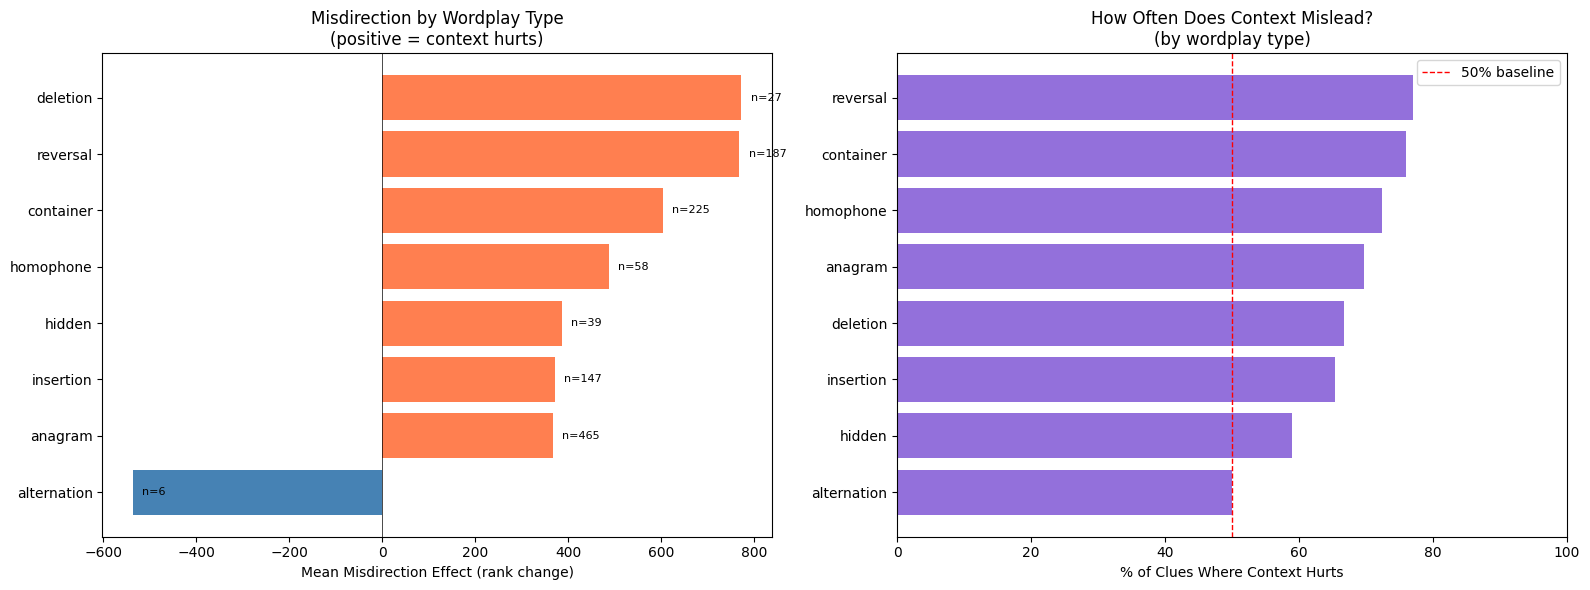

Saved misdirection_by_wordplay.png


In [21]:
# Visualize misdirection by wordplay type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: mean misdirection by type
wp_plot = wp_summary.sort_values('mean_misdirection', ascending=True)
colors = ['coral' if v > 0 else 'steelblue' for v in wp_plot['mean_misdirection']]
axes[0].barh(wp_plot.index, wp_plot['mean_misdirection'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Mean Misdirection Effect (rank change)')
axes[0].set_title('Misdirection by Wordplay Type\n(positive = context hurts)')
for i, (wp, row) in enumerate(wp_plot.iterrows()):
    axes[0].text(row['mean_misdirection'] + 20, i, f'n={row["count"]:.0f}', va='center', fontsize=8)

# Bar chart: % of cases where context hurts
wp_plot2 = wp_summary.sort_values('pct_context_hurts', ascending=True)
axes[1].barh(wp_plot2.index, wp_plot2['pct_context_hurts'] * 100, color='mediumpurple')
axes[1].axvline(x=50, color='red', linestyle='--', linewidth=1, label='50% baseline')
axes[1].set_xlabel('% of Clues Where Context Hurts')
axes[1].set_title('How Often Does Context Mislead?\n(by wordplay type)')
axes[1].set_xlim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/misdirection_by_wordplay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved misdirection_by_wordplay.png')

---
## 11. Summary and Key Findings

### Dataset
- **216,710** single-word-definition clues from Times Crossword and other sources
- Deduplicated to **112,934** unique (definition, answer) pairs; sampled **10,000** for experiments
- Candidate answer pool: **8,598** unique answers

### Baseline: WordNet Synonym Lookup
- **10.5%** of answers are direct WordNet synonyms of their definition word
- This confirms that cryptic crossword definitions go far beyond standard thesaurus relationships — learned semantic representations are needed

### Experiment 1: Context-Free Embeddings (all-mpnet-base-v2)
- Embedding the definition word **alone** (no clue context):
  - Top-1: **3.5%** | Top-10: **20.4%** | Top-100: **43.5%** | Mean Rank: **1,125**
- The model places the correct answer in the top 100 for nearly half of all queries, despite a pool of 8,598 candidates

### Experiment 2: Context-Informed Embeddings (all-mpnet-base-v2)
- Embedding the **full clue text** (definition word in misleading context):
  - Top-1: **1.0%** | Top-10: **7.2%** | Top-100: **24.3%** | Mean Rank: **1,637**
- Performance drops dramatically across every metric when the model sees the full clue

### Core Finding: The Misdirection Effect
- Context **hurts** in **70.4%** of cases, helps in only 28.4%
- Mean rank worsening: **+512 ranks** (median: +146)
- Top-10 accuracy drops by **13.2 percentage points** (20.4% → 7.2%) — a 65% relative decrease
- Mean cosine similarity to the correct answer drops from **0.37 → 0.19**
- **Interpretation:** The clue's surface reading creates measurable semantic misdirection. The surrounding wordplay text actively pushes embedding models toward incorrect meanings, confirming that cryptic crosswords are difficult precisely because of this intentional semantic interference.

### Model Comparison (5,000-pair subset)
| Model | CF Top-1 | CF Top-10 | CF Top-100 | CI Top-1 | CI Top-10 | CI Top-100 |
|-------|----------|-----------|------------|----------|-----------|------------|
| all-MiniLM-L6-v2 (384d) | 3.6% | 16.3% | 36.4% | 0.9% | 7.5% | 24.2% |
| **all-mpnet-base-v2 (768d)** | **6.5%** | **25.7%** | **50.7%** | **1.9%** | **10.4%** | **31.7%** |
| BAAI/bge-m3 (1024d) | 3.8% | 18.9% | 37.6% | 1.5% | 7.1% | 21.4% |

- **All three models** show the same pattern: context-free consistently outperforms context-informed
- MPNet is the best model for this retrieval task (despite BGE-M3 excelling at Victoria's indicator clustering)
- The misdirection effect is **robust across model architectures** — it is not an artifact of a particular embedding model

### Misdirection by Wordplay Type
| Wordplay Type | n | Mean Misdirection | % Context Hurts |
|--------------|---|-------------------|-----------------|
| Deletion | 27 | +772 ranks | 66.7% |
| Reversal | 187 | +768 ranks | 77.0% |
| Container | 225 | +603 ranks | 76.0% |
| Homophone | 58 | +487 ranks | 72.4% |
| Hidden | 39 | +387 ranks | 59.0% |
| Insertion | 147 | +371 ranks | 65.3% |
| Anagram | 465 | +367 ranks | 69.7% |
| Alternation | 6 | **-536 ranks** | 50.0% |

- **Deletion** and **reversal** clues are the most misleading (+772 and +768 mean rank worsening)
- **Alternation** is the only type where context actually helps on average (-536 ranks), though sample size is small (n=6)
- Reversal clues mislead most consistently (77% of cases hurt by context)

---
## 12. Next Steps

### Immediate
1. **Ablation study**: Vary context level systematically (definition only -> definition + 1 adjacent word -> definition + 2 words -> full clue) to see how misdirection scales with context
2. **Deeper per-wordplay analysis**: With more data, break down top-k accuracy by wordplay type (not just misdirection effect)
3. **Cross-encoder reranking**: Train a cross-encoder to score (definition, answer) pairs directly — may learn to "see through" misdirection

### For the Report
4. **Ablation study on features** as discussed with KCT: systematically leave out feature families (POS alignment, frequency, embedding similarity) to measure each family's contribution
5. **Failure analysis** on the best model
6. **Comparison with LLM performance** as a qualitative benchmark

### Infrastructure
7. **Great Lakes HPC**: Sahana confirmed it runs models ~8x faster — use for larger-scale experiments